# LoRA Feasibility

Imports and setup

In [1]:
import os
import pandas as pd
from PIL import Image
import torch

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

GPU available: True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


Check image resolution

In [2]:
dims = [Image.open(f"../data/bodies/{f}").size for f in os.listdir("../data/bodies")[:200]]
print(set(dims))

{(1149, 1665), (569, 1608), (375, 977), (1293, 1483), (384, 998), (531, 953), (559, 1634), (1028, 1667), (579, 1612), (901, 525), (603, 1576), (673, 1573), (374, 978), (426, 1016), (363, 978), (525, 964), (438, 999), (1247, 1546), (289, 662), (573, 1626), (1074, 1764), (1238, 1595), (1482, 781), (533, 943), (366, 796), (945, 1066), (350, 977), (1708, 1166), (1250, 1224), (557, 900), (1243, 1612), (1224, 1553), (1446, 1574), (492, 981), (345, 901), (1038, 1682), (736, 1524), (398, 1010), (599, 1601), (422, 977), (582, 1585), (810, 1092), (1762, 1795), (482, 890), (700, 1497), (431, 979), (322, 920), (802, 1591), (590, 1564), (333, 984), (632, 1579), (929, 1576), (1284, 1578), (668, 1758), (389, 976), (428, 992), (554, 1580), (775, 1612), (969, 1569), (891, 1039), (398, 978), (477, 978), (531, 980), (547, 1577), (931, 1487), (1514, 822), (271, 922), (516, 979), (419, 973), (385, 895), (446, 966), (594, 1563), (1911, 1568), (1276, 1368), (568, 1593), (785, 1545), (968, 1325), (418, 1178),

> Based on the image resolution results, it looks like the image dimensions vary wildly (likely because this dataset contains the chatheads and bodies). It looks like there is more variety in the image sizes of the bodies, which suggests it needs real preprocessing--maybe resizing (nearest-neighbor vs. bicubic resizing) + padding to make them all the same size. 

## EDA on Images in Chatheads and Bodies

Perform some EDA on image sizes (separate the analysis for chatheads vs bodies) to understand how much the spread is for images that need to be preprocessed

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_dims(folder):
    dims = []
    for f in os.listdir(f"../data/{folder}"):
        with Image.open(f"../data/{folder}/{f}") as im:
            dims.append(im.size)
    df = pd.DataFrame(dims, columns=["width", "height"])
    df["aspect_ratio"] = df["width"] / df["height"]
    return df

C:\Users\camiz\AppData\Local\Temp\ipykernel_15652\3860225644.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([chathead_dims["width"], chathead_dims["height"], chathead_dims["aspect_ratio"]],


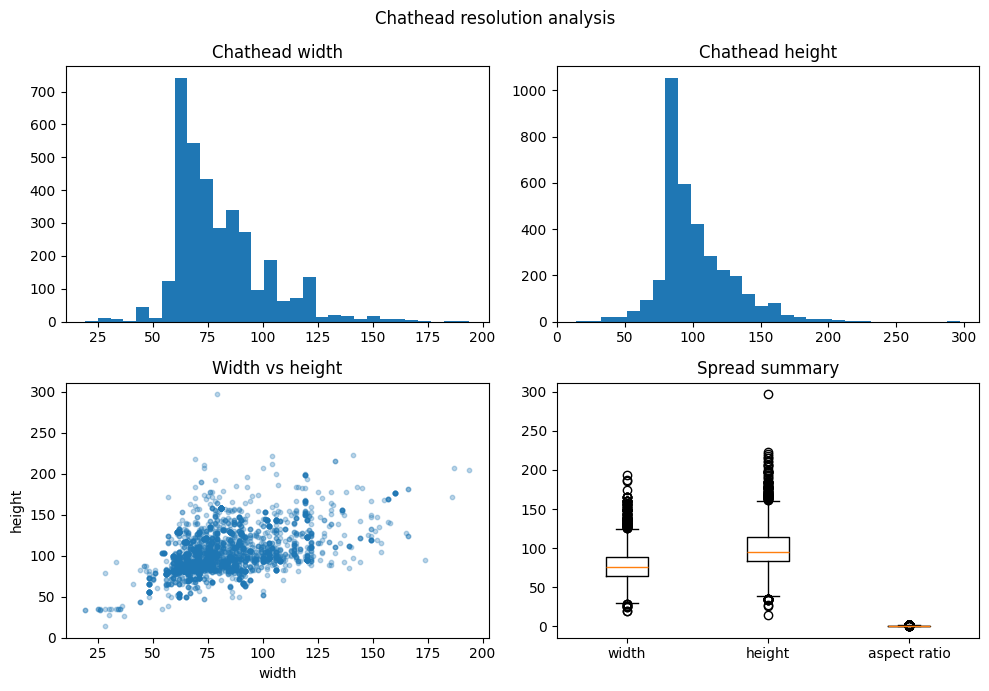

             width       height  aspect_ratio
count  3473.000000  3473.000000   3473.000000
mean     80.179672   100.936654      0.817713
std      20.579311    26.041763      0.197003
min      19.000000    14.000000      0.265993
25%      65.000000    83.000000      0.707071
50%      76.000000    95.000000      0.777174
75%      89.000000   114.000000      0.906780
max     194.000000   297.000000      2.000000


In [4]:
# Chatheads
chathead_dims = get_dims("chatheads")

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0,0].hist(chathead_dims["width"], bins=30); axes[0,0].set_title("Chathead width")
axes[0,1].hist(chathead_dims["height"], bins=30); axes[0,1].set_title("Chathead height")
axes[1,0].scatter(chathead_dims["width"], chathead_dims["height"], alpha=0.3, s=10)
axes[1,0].set_title("Width vs height"); axes[1,0].set_xlabel("width"); axes[1,0].set_ylabel("height")
axes[1,1].boxplot([chathead_dims["width"], chathead_dims["height"], chathead_dims["aspect_ratio"]],
                   labels=["width", "height", "aspect ratio"])
axes[1,1].set_title("Spread summary")
plt.suptitle("Chathead resolution analysis")
plt.tight_layout()
plt.savefig("../img/chathead_resolution_eda.png")
plt.show()

print(chathead_dims.describe())

> `Chathead` images are easier to preprocess first since most images tend to be the same size. It should be fairly easy to resize and pad without compromising information loss. 

C:\Users\camiz\AppData\Local\Temp\ipykernel_15652\625409771.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([body_dims["width"], body_dims["height"], body_dims["aspect_ratio"]],


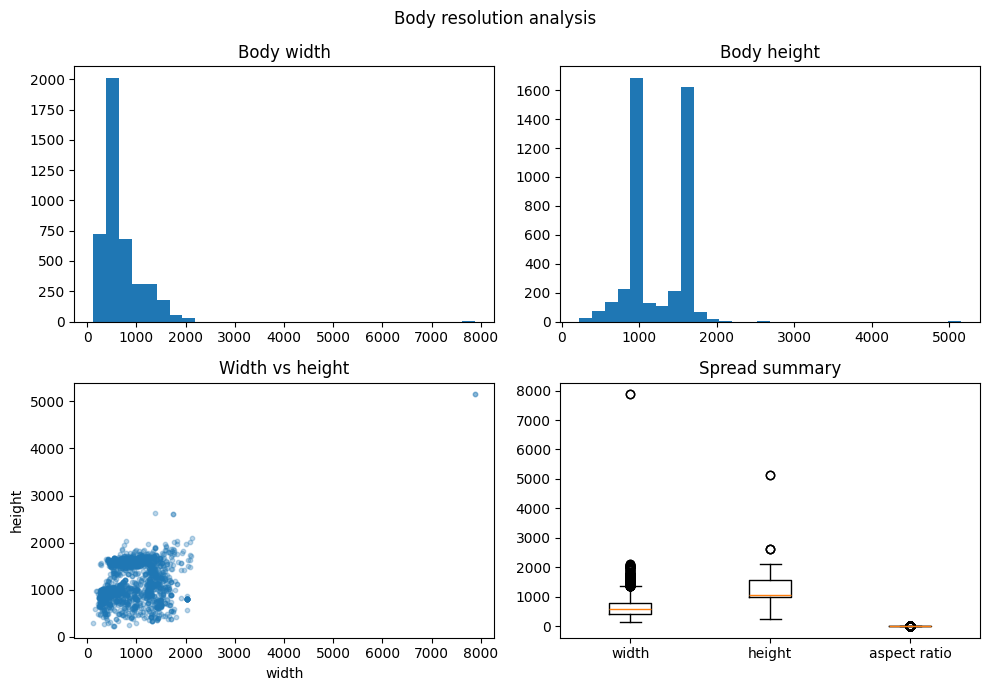

             width       height  aspect_ratio
count  4301.000000  4301.000000   4301.000000
mean    687.372704  1233.700070      0.608927
std     390.185444   361.397392      0.473975
min     128.000000   230.000000      0.173213
25%     420.000000   973.000000      0.376663
50%     575.000000  1058.000000      0.431959
75%     796.000000  1578.000000      0.605216
max    7880.000000  5150.000000      4.355499


In [5]:
# Bodies 
body_dims = get_dims("bodies")

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0,0].hist(body_dims["width"], bins=30); axes[0,0].set_title("Body width")
axes[0,1].hist(body_dims["height"], bins=30); axes[0,1].set_title("Body height")
axes[1,0].scatter(body_dims["width"], body_dims["height"], alpha=0.3, s=10)
axes[1,0].set_title("Width vs height"); axes[1,0].set_xlabel("width"); axes[1,0].set_ylabel("height")
axes[1,1].boxplot([body_dims["width"], body_dims["height"], body_dims["aspect_ratio"]],
                   labels=["width", "height", "aspect ratio"])
axes[1,1].set_title("Spread summary")
plt.suptitle("Body resolution analysis")
plt.tight_layout()
plt.savefig("../img/body_resolution_eda.png")
plt.show()

print(body_dims.describe())

> Images in the `bodies` dataset are more spread out. Might be worth looking  into the images that are outliers and see what the risks are if we preprocess these.

Build caption manifest
> *manifest = index file containing which the training script reads 

In [6]:
attrs = pd.read_csv("../data/npc_attributes.csv")
npc = pd.read_csv("../data/npc.csv")[["id", "Location"]]
manifest = attrs.merge(npc, on="id", how="left")

def finalize_caption(row):
    base = row["caption"] if pd.notna(row["caption"]) else "an OSRS character"
    if pd.notna(row["Location"]):
        base += f", found in {row['Location']}"
    return base

manifest["final_caption"] = manifest.apply(finalize_caption, axis=1)
manifest[["id", "final_caption"]].sample(5)

,id,final_caption
1434,1434,"Fishing spot, found in Piscatoris Fishing Colony"
4158,4158,"Vallessia Dracyula: Vampyre, female, a goatee,..."
4040,4040,"Trader: Dwarf, male, a beard, red hair, a helm..."
4202,4202,"Viking woman: Human, female, found in ? (edit)"
4139,4139,"Ur-taal: Dorgeshuun, female, glasses, found in..."


Filter to images that exist and split by type

In [7]:
chathead_ids = {int(f.split(".")[0]) for f in os.listdir("../data/chatheads")}
body_ids = {int(f.split(".")[0]) for f in os.listdir("../data/bodies")}

chathead_manifest = manifest[manifest["id"].isin(chathead_ids)].copy()
chathead_manifest["image_path"] = chathead_manifest["id"].apply(lambda i: f"../data/chatheads/{i}.png")

body_manifest = manifest[manifest["id"].isin(body_ids)].copy()
body_manifest["image_path"] = body_manifest["id"].apply(lambda i: f"../data/bodies/{i}.png")

print(len(chathead_manifest), len(body_manifest))

3473 4301


Save chathead manifest to disk (so the code runs faster)

In [8]:
chathead_manifest[["image_path", "final_caption"]].to_csv(
    "../data/chathead_lora_manifest.csv", index=False
)
print(len(chathead_manifest), "rows saved")

3473 rows saved


## Chatheads Image Preprocessing

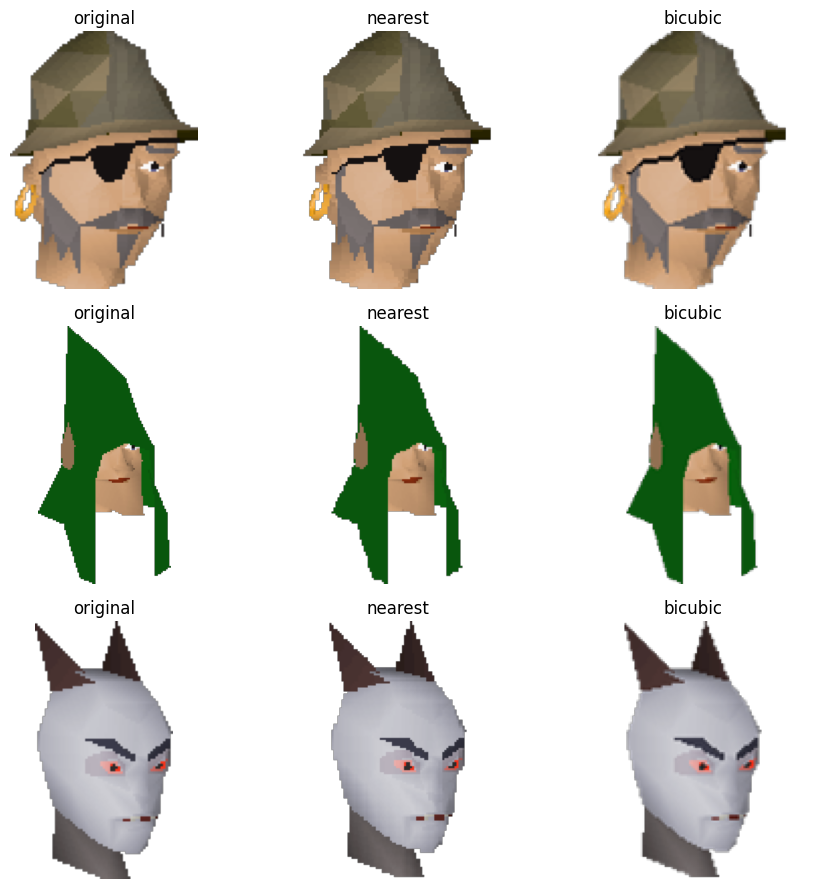

In [9]:
MIN_DIM = 30
TARGET_SIZE = 128

def resize_and_pad(img, target_size=TARGET_SIZE, resample=Image.NEAREST):
    img = img.convert("RGBA")
    w, h = img.size
    scale = target_size / max(w, h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = img.resize((new_w, new_h), resample)

    canvas = Image.new("RGBA", (target_size, target_size), (0, 0, 0, 0))
    paste_x = (target_size - new_w) // 2
    paste_y = (target_size - new_h) // 2
    canvas.paste(resized, (paste_x, paste_y), resized)
    return canvas

# quick visual test: nearest vs bicubic, on a few samples
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
sample_ids = chathead_manifest["id"].sample(3, random_state=1).tolist()
for row, npc_id in enumerate(sample_ids):
    img = Image.open(f"../data/chatheads/{npc_id}.png")
    axes[row, 0].imshow(img); axes[row, 0].set_title("original")
    axes[row, 1].imshow(resize_and_pad(img, resample=Image.NEAREST)); axes[row, 1].set_title("nearest")
    axes[row, 2].imshow(resize_and_pad(img, resample=Image.BICUBIC)); axes[row, 2].set_title("bicubic")
    for ax in axes[row]: ax.axis("off")
plt.tight_layout()
plt.show()

> Based on the results, above **bicubic** looks the smoothest but nearest-neighbor looks truer to the OG OSRS art style. I'll experiment with nearest-neighbor first and see what the image generation output looks like. 

Pipeline Components Explained
1. VAE (Variational Autoencoder)
> Simple Explanation: An image compression tool, like a zip file for pixels.Functional Role: Standard $512 \times 512$ or $128 \times 128$ pixel images have too many dimensions for a GPU to denoise efficiently. The VAE Encoder compresses pixel space into a smaller "latent space" representation (reducing spatial dimensions by a factor of 8). The U-Net does all its work in this small latent space. Once denoising is finished, the VAE Decoder unpacks those latents back into visible RGB pixels.
2. CLIP Text Encoder
> Simple Explanation: A translator converting human words into spatial concepts.Functional Role: CLIP takes your text caption (e.g., "an OSRS wizard with a dark robe") and turns it into a mathematical vector representation. It doesn't generate images; it provides spatial "guidance instructions" to the U-Net so the output matches the text.
3. U-Net Denoiser
> Simple Explanation: The actual artist removing static to reveal an image.Functional Role: This is the core neural network. It takes a noisy latent vector, receives text vectors from CLIP via cross-attention, and predicts how much noise to subtract to get closer to a coherent latent image. This is what you fine-tune.

**Key Hyperparameters for Fine-Tuning & Troubleshooting**
> When troubleshooting bad outputs during LoRA fine-tuning, these are the primary parameters you adjust:

| Hyperparameter | What It Controls | Troubleshooting |
|----------------|------------------|-----------------|
|Impact LoRA Rank ($r$) | Dimensionality of the LoRA matrices ($A \cdot B$).| **Too Low** ($r=2\text{--}4$): Output looks generic; fails to capture fine OSRS features. <br> **Too High** ($r=32\text{--}64$): Overfits quickly, wastes VRAM, and can cause training instability.
|LoRA Alpha ($\alpha$) | Scaling factor applied to LoRA updates. | Acts as weight strength. Higher values force the model to prioritize the LoRA adapter over the base Stable Diffusion model. Standard practice: set $\alpha = r$ or $\alpha = 2r$.
|Learning Rate ($lr$)| Speed of weight adjustments (typically $10^{-4}$ to $10^{-5}$). | **Too High** ($>10^{-3}$): Output breaks into random color noise/artifacts. <br> **Too Low** ($<10^{-6}$): Model barely changes; output looks like default SD 1.5.
|Training Steps / Epochs | How long the model trains on the dataset. | **Underfitted**: Character shapes are smooth photorealistic humans instead of OSRS low-poly style.<br> **Overfitted**: Generates exact duplicates of training images, ignoring prompt text.
|Resolution | Target dimension fed to VAE ($128 \times 128$). | Mismatches between preprocessed padding and target dimensions cause severe stretching or blurriness.